In [5]:
import ateams
import networkx as nx

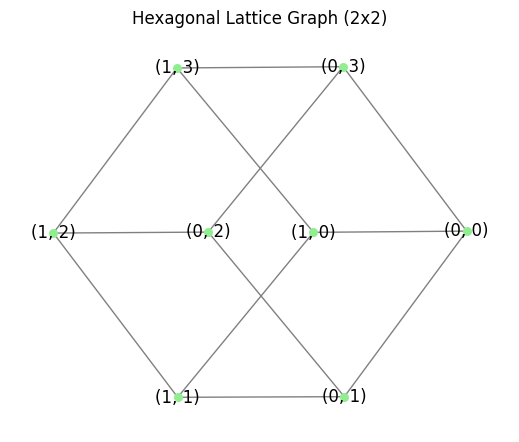

In [50]:
import matplotlib.pyplot as plt

rows, cols = 2, 2
G = nx.hexagonal_lattice_graph(rows, cols, periodic=True)

pos = nx.get_node_attributes(G, 'pos')

plt.figure(figsize=(5, 4))
nx.draw(
    G, 
    # pos, 
    with_labels=True, 
    node_size=30, 
    node_color="lightgreen", 
    edge_color="gray"
)

plt.title(f"Hexagonal Lattice Graph ({rows}x{cols})")
plt.axis('off')
plt.show()

In [51]:
nx.to_numpy_array(G)

array([[0., 1., 0., 1., 1., 0., 0., 0.],
       [1., 0., 1., 0., 0., 1., 0., 0.],
       [0., 1., 0., 1., 0., 0., 1., 0.],
       [1., 0., 1., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 1., 0., 1.],
       [0., 1., 0., 0., 1., 0., 1., 0.],
       [0., 0., 1., 0., 0., 1., 0., 1.],
       [0., 0., 0., 1., 1., 0., 1., 0.]])

In [13]:
n = 3
for i in range(0, 2*n-1):
    print((i, i+1))
print((2*n-1, 0))

(0, 1)
(1, 2)
(2, 3)
(3, 4)
(4, 5)
(5, 0)


In [18]:
n = 3
for j in range(n):
    for i in range(j * (2*n) + 0, j * (2*n) + 2*n-1):
        print((i, i+1))
    print((j * (2*n) + 2*n-1, j * (2*n)))

(0, 1)
(1, 2)
(2, 3)
(3, 4)
(4, 5)
(5, 0)
(6, 7)
(7, 8)
(8, 9)
(9, 10)
(10, 11)
(11, 6)
(12, 13)
(13, 14)
(14, 15)
(15, 16)
(16, 17)
(17, 12)


In [1]:
c = []
n = 3
for j in range(n):
    temp = []
    for i in range(j * (2*n) + 0, j * (2*n) + 2*n-1):
        temp.append((i, i+1))
    temp.append((j * (2*n) + 2*n-1, j * (2*n)))
    c.append(temp)
print(c)

print("-"*50)

for j in range(1):
    for i in range(n):
        print((c[j][2*i][0], c[(j+1)%n][2*i][0]))

for j in range(1, n):
    for i in range(n):
        print((c[j][2*i][1], c[(j+1)%n][2*i][0]))

print("-"*50)

for j in range(1):
    for i in range(n):
        print((c[j][2*i][0], c[j][2*i][1], c[j][(2*i+1)%(2*n)][1], c[(j+1)%n][2*i][0], c[(j+1)%n][2*i][1], c[(j+1)%n][(2*i+1)%(2*n)][1]))

for j in range(1, n):
    for i in range(n):
        print((c[j][2*i+1][0], c[j][2*i+1][1], c[j][(2*i+2)%(2*n)][1], c[(j+1)%n][2*i][0], c[(j+1)%n][2*i][1], c[(j+1)%n][(2*i+1)%(2*n)][1]))

[[(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)], [(6, 7), (7, 8), (8, 9), (9, 10), (10, 11), (11, 6)], [(12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 12)]]
--------------------------------------------------
(0, 6)
(2, 8)
(4, 10)
(7, 12)
(9, 14)
(11, 16)
(13, 0)
(15, 2)
(17, 4)
--------------------------------------------------
(0, 1, 2, 6, 7, 8)
(2, 3, 4, 8, 9, 10)
(4, 5, 0, 10, 11, 6)
(7, 8, 9, 12, 13, 14)
(9, 10, 11, 14, 15, 16)
(11, 6, 7, 16, 17, 12)
(13, 14, 15, 0, 1, 2)
(15, 16, 17, 2, 3, 4)
(17, 12, 13, 4, 5, 0)


In [23]:
from itertools import chain

class Hexagon:
    def __init__(self, n):
        self.n = n
        self.edges = self.create_edges()
        self.faces =self.create_faces()

    def create_edges(self):
        edges = []
        for j in range(self.n):
            temp = []
            for i in range(j * (2*self.n) + 0, j * (2*self.n) + 2*self.n-1):
                temp.append((i, i+1))
            temp.append((j * (2*self.n) + 2*self.n-1, j * (2*self.n)))
            edges.append(temp)

        edges = list(chain.from_iterable(edges))

        for j in range(1):
            for i in range(self.n):
                edges.append((c[j][2*i][0], c[(j+1)%self.n][2*i][0]))

        for j in range(1, self.n):
            for i in range(self.n):
                edges.append((c[j][2*i][1], c[(j+1)%self.n][2*i][0]))

        return edges
    
    def create_faces(self):
        faces = []

        for j in range(1):
            for i in range(self.n):
                faces.append([(c[j][2*i][0], c[j][2*i][1]),
                             (c[j][2*i][1], c[j][(2*i+1)%(2*self.n)][1]),
                             (c[j][(2*i+1)%(2*self.n)][1], c[(j+1)%self.n][(2*i+1)%(2*self.n)][1]),
                             (c[(j+1)%self.n][(2*i+1)%(2*self.n)][1], c[(j+1)%self.n][2*i][1]),
                             (c[(j+1)%self.n][2*i][1], c[(j+1)%self.n][2*i][0]),
                             (c[(j+1)%self.n][2*i][0], c[j][2*i][0])])
        
        for j in range(1, self.n):
            for i in range(self.n):
                faces.append([(c[j][2*i+1][0], c[j][2*i+1][1]),
                             (c[j][2*i+1][1], c[j][(2*i+2)%(2*self.n)][1]),
                             (c[j][(2*i+2)%(2*self.n)][1], c[(j+1)%self.n][(2*i+1)%(2*self.n)][1]),
                             (c[(j+1)%self.n][(2*i+1)%(2*self.n)][1], c[(j+1)%self.n][2*i][1]),
                             (c[(j+1)%self.n][2*i][1], c[(j+1)%self.n][2*i][0]),
                             (c[(j+1)%self.n][2*i][0], c[j][2*i+1][0])])

        return faces

In [24]:
hex = Hexagon(3)